## Módulo 19 - Transformação de Variáveis


# Projeto de Regressão Linear: Precificação de Imóveis

## Objetivo
Estimar preços dos imóveis de acordo com diversas características das propriedades, como área e localização. Para este propósito, vamos:

* **Identificar** quais fatores contribuem para a precificação dos imóveis;
* **Averiguar** a influência das características no preço do imóvel;
* **Diferenciar** quando precisamos transformar ou não as variáveis para uma melhor resposta do modelo;
* **Verificar** a relação entre as variáveis explicativas e a variável resposta;
* **Criar** um modelo de regressão linear de múltiplas variáveis;
* **Fazer** previsões para uma ou mais casas.

## Base de Dados
Vamos utilizar a base `precos_casa.csv`, adaptada de uma base bem conhecida no Kaggle chamada [House Prices](https://kaggle.com). Esses dados serão lidos a partir do repositório compartilhado pelo GitHub.


In [233]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [234]:
# Alternativa caso o link falhe: usando seu arquivo local
dados = pd.read_csv(r'Dados\precos_casas.csv')

# Filtrando e ordenando as colunas
ordem_colunas = ['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal', 'dist_metro', 'dist_parque']
dados = dados[ordem_colunas].round(2)
dados.head()




,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
0,1042500,79.52,1,23.86,1.64,3.04
1,907500,117.24,0,35.17,1.54,10.91
2,1117500,85.47,1,25.64,1.27,11.79
3,700000,89.28,1,21.07,1.22,10.88
4,1250000,106.37,1,31.91,0.87,11.25


In [235]:
dados.shape

(1460, 6)

In [236]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor                 1460 non-null   int64  
 1   area_primeiro_andar   1460 non-null   float64
 2   existe_segundo_andar  1460 non-null   int64  
 3   area_quintal          1460 non-null   float64
 4   dist_metro            1460 non-null   float64
 5   dist_parque           1460 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 68.6 KB


# 1.3 - Entendendo a relação dos dados

Para entender a relação dos dados entre o valor de venda dos imóveis do dataset e suas características vamos utilizar a **Correlação**.

Correlação é uma medida estatística que varia numa escala de -1 a 1, indicando a relação e a dependência entre duas variáveis. Existem três tipos principais de correlação:

1. **Correlação Positiva**: quando uma variável aumenta, a outra tende a aumentar.
2. **Correlação Nula**: não há relação linear entre as variáveis.
3. **Correlação Negativa**: quando uma variável aumenta, a outra tende a diminuir.

Essa medida não só define a direção, como também, a intensidade da relação.


In [237]:
# .corr(): Calcula os coeficientes de correlação linear entre todas as colunas numéricas
# .round(3): Arredonda os valores resultantes para exibir exatamente 3 casas decimais
corr = dados.corr().round(3)

# Exibe a matriz de correlação gerada na tela do notebook
corr


,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
valor,1.000,0.606,0.138,0.614,-0.644,-0.072
area_primeiro_andar,0.606,1.000,-0.339,0.820,-0.369,-0.058
existe_segundo_andar,0.138,-0.339,1.000,-0.301,-0.191,-0.007
area_quintal,0.614,0.820,-0.301,1.000,-0.440,-0.058
dist_metro,-0.644,-0.369,-0.191,-0.440,1.000,0.089
dist_parque,-0.072,-0.058,-0.007,-0.058,0.089,1.000


In [238]:
# corr["valor"]: Filtra apenas a coluna de preço ('valor') dentro da matriz de correlação
# .to_frame(): Transforma a série resultante em uma tabela (DataFrame) para ficar mais visual
corr["valor"].to_frame()


,valor
valor,1.000
area_primeiro_andar,0.606
existe_segundo_andar,0.138
area_quintal,0.614
dist_metro,-0.644
dist_parque,-0.072


# 1.4 - Visualizando uma Regressão Linear com uma variável independente

Já compreendemos um pouco a relação entre as variáveis e o valor de venda das casas. Mas que tal observarmos isso visualmente, pegando apenas uma das variáveis de nossa base?

>Aqui vamos apenas observar o comportamento da variável `valor` em relação a `area_primeiro_andar` rodando um modelo de regressão linear dentro da função `reg_plot()` da biblioteca `seaborn`. Mais a frente implementaremos o nosso próprio modelo!


In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

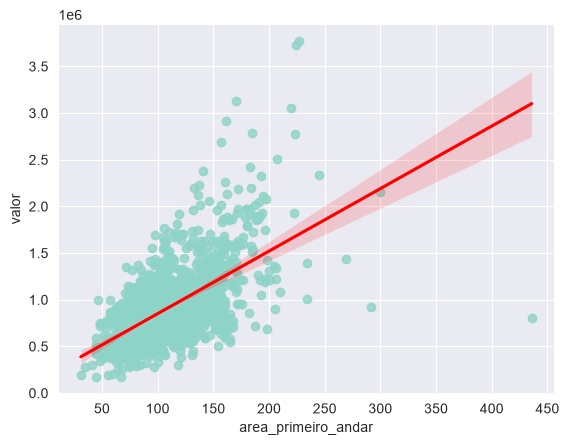

In [240]:
sns.set_style("darkgrid")
sns.regplot(x="area_primeiro_andar", y="valor", data=dados, line_kws={'color':'red'})
plt.show()

In [241]:
# Importa as ferramentas necessárias para renderizar Markdown dentro do código Python
from IPython.display import display, Markdown

# Armazena todo o texto explicativo e as fórmulas em formato string
conteudo_teorico = """
### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \\beta_0 + \\beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).
"""

# Renderiza e exibe o bloco formatado perfeitamente na tela
display(Markdown(conteudo_teorico))



### 1.5 - A Equação da Regressão Linear Simples

A fórmula matemática que descreve o modelo de regressão linear que acabamos de visualizar graficamente é definida por:

$$Y = \beta_0 + \beta_1 X + e$$

Onde cada componente representa:

* **$Y$ (Variável Resposta)**: É a variável dependente que queremos prever (no nosso caso, o `valor` do imóvel).
* **$\beta_0$ (Intercepto)**: O ponto onde a linha de regressão corta o eixo Y.
* **$\beta_1$ (Coeficiente Angular)**: A inclinação da reta, indicando o impacto de $X$ em $Y$.
* **$X$ (Variável Explicativa)**: A variável independente usada para fazer a previsão (a `area_primeiro_andar`).
* **$e$ (Erro)**: O resíduo (diferença entre o valor real e o previsto).


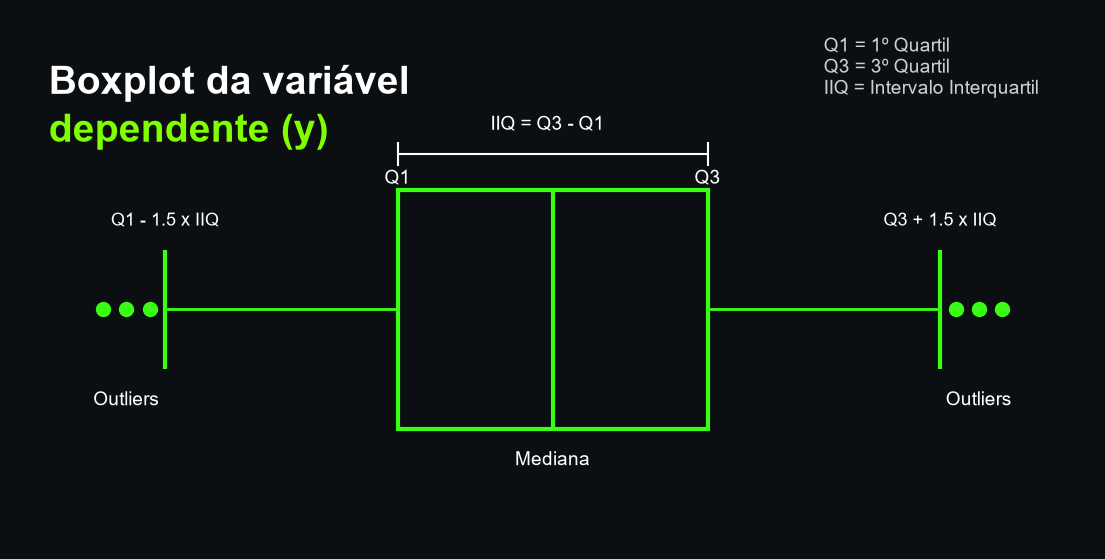

In [242]:
import base64
import io
import matplotlib.pyplot as plt


def gerar_layout_boxplot():
    # Define o estilo visual escuro idêntico ao slide do curso
    plt.style.use("dark_background")

    # Cria a figura com um tamanho grande e nítido
    fig, ax = plt.subplots(figsize=(14, 7), facecolor="#0B0F12")
    ax.set_facecolor("#0B0F12")

    # Desenha a caixa principal do Boxplot (Verde Neon)
    # Q1 = 4, Mediana = 6, Q3 = 8
    rect = plt.Rectangle(
        (4, 2), 4, 2, edgecolor="#39FF14", facecolor="none", linewidth=3
    )
    ax.add_patch(rect)

    # Linha da Mediana
    ax.vlines(6, 2, 4, colors="#39FF14", linewidth=3)

    # Bigodes (Whiskers) e Limites (Q1 - 1.5*IIQ = 1 e Q3 + 1.5*IIQ = 11)
    ax.hlines(3, 1, 4, colors="#39FF14", linewidth=2)
    ax.hlines(3, 8, 11, colors="#39FF14", linewidth=2)
    ax.vlines(1, 2.5, 3.5, colors="#39FF14", linewidth=3)  # Limite Inferior
    ax.vlines(11, 2.5, 3.5, colors="#39FF14", linewidth=3)  # Limite Superior

    # Desenha os Outliers (Pontos Verdes além dos limites)
    ax.scatter([0.2, 0.5, 0.8], [3, 3, 3], color="#39FF14", s=100)
    ax.scatter([11.2, 11.5, 11.8], [3, 3, 3], color="#39FF14", s=100)

    # ---- TEXTOS E LEGENDA DO LAYOUT ----

    # Título principal do slide
    ax.text(
        -0.5,
        4.8,
        "Boxplot da variável",
        fontsize=28,
        weight="bold",
        color="white",
    )
    ax.text(
        -0.5,
        4.4,
        "dependente (y)",
        fontsize=28,
        weight="bold",
        color="#7FFF00",
    )

    # Equações e Legendas Estatísticas (Canto Superior Direito)
    ax.text(
        9.5,
        4.8,
        "Q1 = 1º Quartil\nQ3 = 3º Quartil\nIIQ = Intervalo Interquartil",
        fontsize=14,
        color="white",
        alpha=0.8,
    )

    # Linha e texto do IIQ (Intervalo Interquartil)
    ax.hlines(4.3, 4, 8, colors="white", linewidth=1.5)
    ax.vlines(4, 4.2, 4.4, colors="white", linewidth=1.5)
    ax.vlines(8, 4.2, 4.4, colors="white", linewidth=1.5)
    ax.text(5.2, 4.5, "IIQ = Q3 - Q1", fontsize=14, color="white")

    # Textos das marcações dos Quartis e Limites
    ax.text(4, 4.05, "Q1", fontsize=14, color="white", ha="center")
    ax.text(8, 4.05, "Q3", fontsize=14, color="white", ha="center")
    ax.text(6, 1.7, "Mediana", fontsize=14, color="white", ha="center")

    # Fórmulas dos limites nas pontas dos bigodes
    ax.text(1, 3.7, "Q1 - 1.5 x IIQ", fontsize=13, color="white", ha="center")
    ax.text(11, 3.7, "Q3 + 1.5 x IIQ", fontsize=13, color="white", ha="center")

    # Rótulos de Outliers
    ax.text(0.5, 2.2, "Outliers", fontsize=14, color="white", ha="center")
    ax.text(11.5, 2.2, "Outliers", fontsize=14, color="white", ha="center")

    # Configurações de exibição (Esconde os eixos normais para focar no layout)
    ax.set_xlim(-1, 13)
    ax.set_ylim(1, 5.5)
    ax.axis("off")

    # Renderiza e exibe o gráfico grande
    plt.show()


# Executa a função para desenhar a imagem no notebook
gerar_layout_boxplot()


O **boxplot** é uma apresentação visual que mostra a distribuição de dados quantitativos, facilitando comparações entre variáveis ou categorias.

Os elementos principais de um boxplot são:

* **Caixa:** Representa o intervalo interquartil (IIQ), que vai do primeiro quartil (Q1 - 25% dos dados) ao terceiro quartil (Q3 - 75% dos dados).
* **Linha mediana:** Onde está posicionada a mediana (Q2), valor que separa 50% dos dados.
* **Whiskers ("bigodes"):** Extensões que mostram a variabilidade fora do intervalo interquartil, geralmente até 1,5 vezes o IIQ a partir dos quartis.
* **Outliers:** Pontos individuais que estão fora do alcance dos *whiskers*, indicados separadamente.

Essa visualização ajuda a identificar a centralidade, dispersão e possíveis *outliers* em um conjunto de dados.


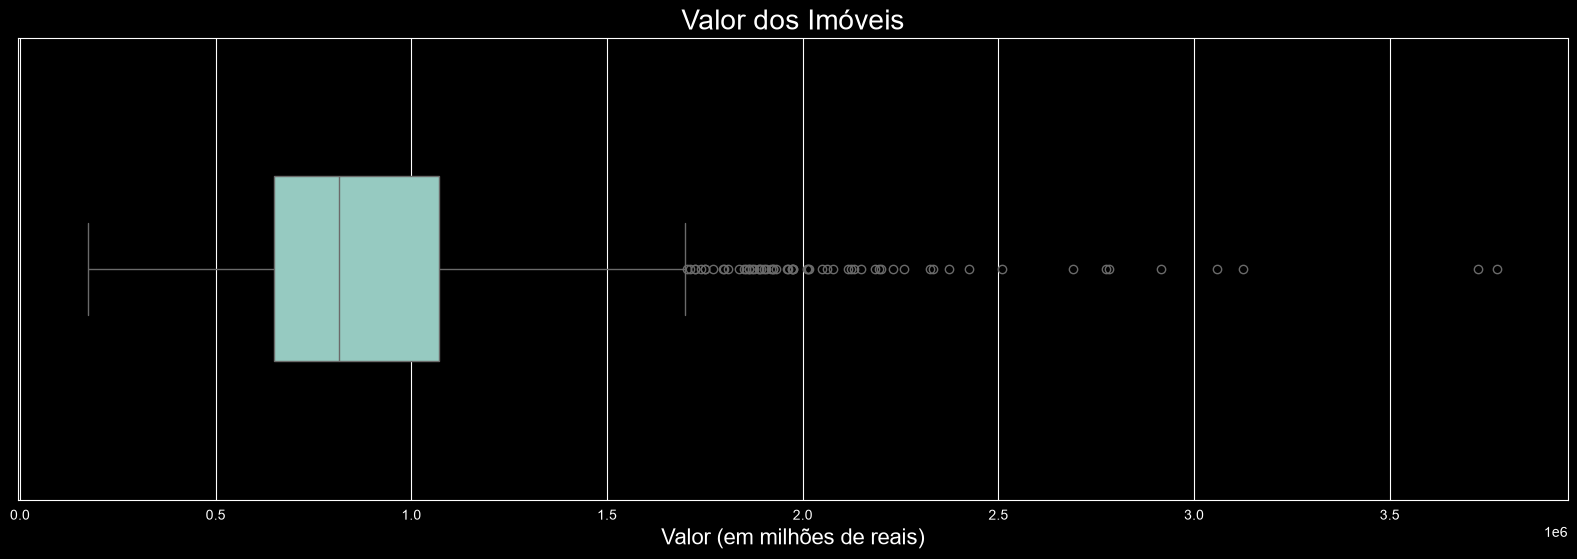

In [243]:
ax = sns.boxplot(dados, x ="valor", width=0.4)

ax.figure.set_size_inches(20, 6)
ax.set_title('Valor dos Imóveis', fontsize=20)
ax.set_xlabel('Valor (em milhões de reais)', fontsize=16)
plt.show()

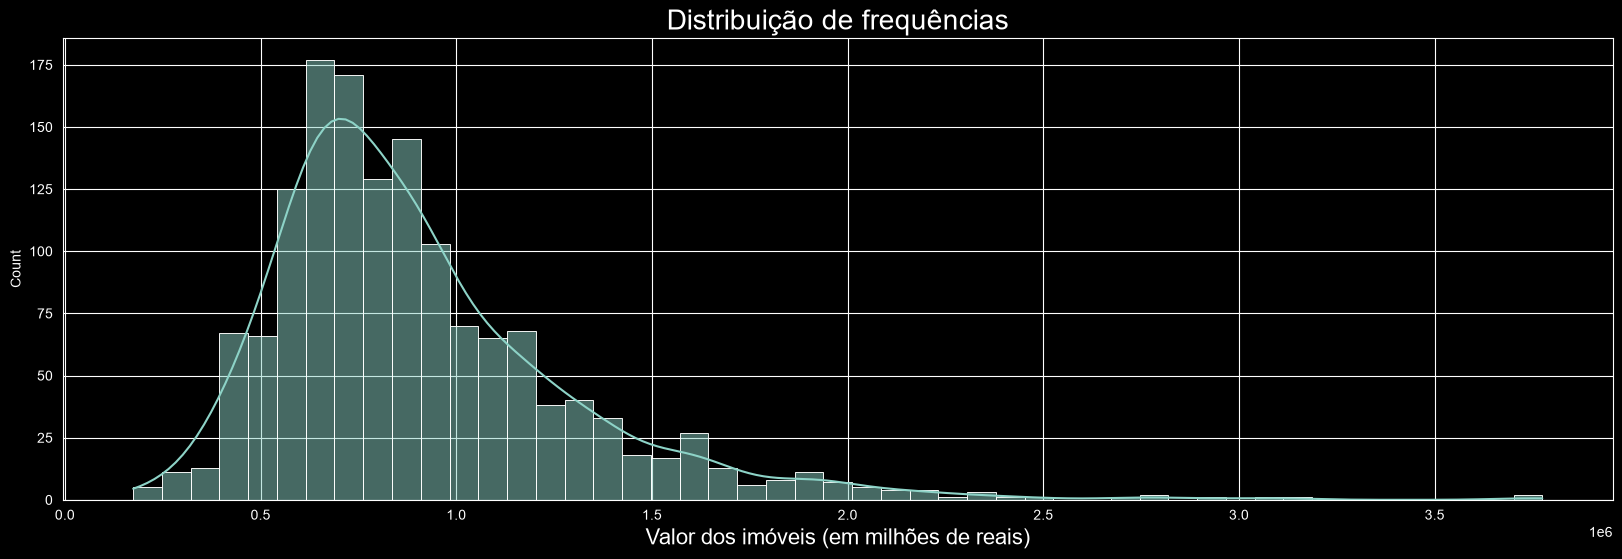

In [244]:
ax = sns.histplot(dados['valor'], kde=True)

ax.figure.set_size_inches(20, 6)
ax.set_title('Distribuição de frequências', fontsize=20)
ax.set_xlabel('Valor dos imóveis (em milhões de reais)', fontsize=16)
plt.show()

# Gráfico de Densidade

Um gráfico de densidade é uma versão suavizada do histograma, utilizando uma função de densidade para estimar a distribuição de uma variável contínua. Diferente do histograma, que usa "bins" para agrupar os dados, o gráfico de densidade cria uma curva contínua que representa essa distribuição.

Os três tipos básicos de um gráfico de densidade são:

### 1. Distribuição Assimétrica à Direita (Positivamente Assimétrica)
* A cauda longa da curva está localizada à **direita** da mediana.
* Neste caso, a **média** dos dados é **maior** que a mediana ($\text{Média} > \text{Mediana}$).

### 2. Distribuição Simétrica
* A distribuição é espelhada e equilibrada em torno das medidas de tendência central.
* A característica principal é que a **média**, a **mediana** e a **moda** são iguais ou muito próximas ($\text{Média} \approx \text{Mediana} \approx \text{Moda}$).

### 3. Distribuição Assimétrica à Esquerda (Negativamente Assimétrica)
* A cauda longa da curva está localizada à **esquerda** da mediana.
* Neste caso, a **média** dos dados é **menor** que a mediana ($\text{Média} < \text{Mediana}$).


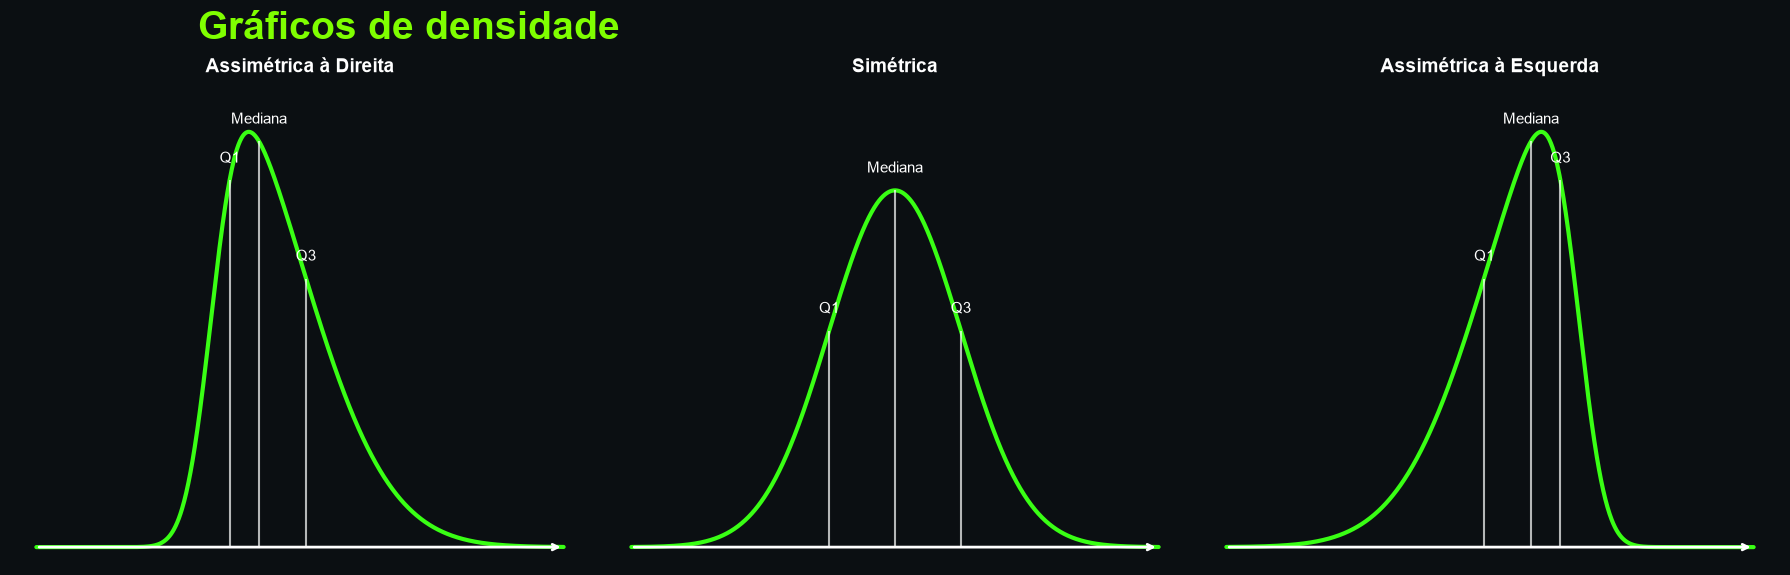

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm, norm

# Configura o estilo visual escuro idêntico ao slide do curso
plt.style.use('dark_background')

# Cria a figura com um tamanho grande e nítido
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0B0F12')

# Título principal do slide adicionado no topo da figura geral
fig.suptitle('Gráficos de densidade', fontsize=28, weight='bold', color='#7FFF00', x=0.23, y=0.95)

# Configurações de dados para gerar as curvas suavizadas
x_sym = np.linspace(-4, 4, 1000)
y_sym = norm.pdf(x_sym, 0, 1)

x_right = np.linspace(-2, 7, 1000)
y_right = skewnorm.pdf(x_right, 4, 1, 1.5)

x_left = np.linspace(-7, 2, 1000)
y_left = skewnorm.pdf(x_left, -4, -1, 1.5)

# --- 1. CURVA ASSIMÉTRICA À DIREITA ---
ax = axes[0]
ax.set_facecolor('#0B0F12')
ax.plot(x_right, y_right, color='#39FF14', linewidth=3)
ax.set_title('Assimétrica à Direita', fontsize=14, weight='bold', pad=20)
# Linhas verticais para Q1, Mediana (Q2) e Q3 baseadas no formato visual do slide
ax.vlines(x=1.3, ymin=0, ymax=y_right[np.abs(x_right - 1.3).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=1.8, ymin=0, ymax=y_right[np.abs(x_right - 1.8).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=2.6, ymin=0, ymax=y_right[np.abs(x_right - 2.6).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.text(1.3, y_right[np.abs(x_right - 1.3).argmin()]+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(1.8, y_right[np.abs(x_right - 1.8).argmin()]+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(2.6, y_right[np.abs(x_right - 2.6).argmin()]+0.02, 'Q3', fontsize=11, color='white', ha='center')
# Seta do eixo X
ax.annotate('', xy=(7, 0), xytext=(-2, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# --- 2. CURVA SIMÉTRICA ---
ax = axes[1]
ax.set_facecolor('#0B0F12')
ax.plot(x_sym, y_sym, color='#39FF14', linewidth=3)
ax.set_title('Simétrica', fontsize=14, weight='bold', pad=20)
ax.vlines(x=-1.0, ymin=0, ymax=norm.pdf(-1.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=0.0, ymin=0, ymax=norm.pdf(0.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=1.0, ymin=0, ymax=norm.pdf(1.0, 0, 1), colors='white', linewidth=1.5, alpha=0.7)
ax.text(-1.0, norm.pdf(-1.0, 0, 1)+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(0.0, norm.pdf(0.0, 0, 1)+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(1.0, norm.pdf(1.0, 0, 1)+0.02, 'Q3', fontsize=11, color='white', ha='center')
ax.annotate('', xy=(4, 0), xytext=(-4, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# --- 3. CURVA ASSIMÉTRICA À ESQUERDA ---
ax = axes[2]
ax.set_facecolor('#0B0F12')
ax.plot(x_left, y_left, color='#39FF14', linewidth=3)
ax.set_title('Assimétrica à Esquerda', fontsize=14, weight='bold', pad=20)
ax.vlines(x=-2.6, ymin=0, ymax=y_left[np.abs(x_left - -2.6).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=-1.8, ymin=0, ymax=y_left[np.abs(x_left - -1.8).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.vlines(x=-1.3, ymin=0, ymax=y_left[np.abs(x_left - -1.3).argmin()], colors='white', linewidth=1.5, alpha=0.7)
ax.text(-2.6, y_left[np.abs(x_left - -2.6).argmin()]+0.02, 'Q1', fontsize=11, color='white', ha='center')
ax.text(-1.8, y_left[np.abs(x_left - -1.8).argmin()]+0.02, 'Mediana', fontsize=11, color='white', ha='center')
ax.text(-1.3, y_left[np.abs(x_left - -1.3).argmin()]+0.02, 'Q3', fontsize=11, color='white', ha='center')
ax.annotate('', xy=(2, 0), xytext=(-7, 0), arrowprops=dict(arrowstyle="->", color="white", lw=2))

# Limpeza estética geral (remove bordas desnecessárias)
for ax in axes:
    ax.set_ylim(-0.02, 0.5)
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()


In [246]:
dados.columns

Index(['valor', 'area_primeiro_andar', 'existe_segundo_andar', 'area_quintal',
       'dist_metro', 'dist_parque'],
      dtype='str')

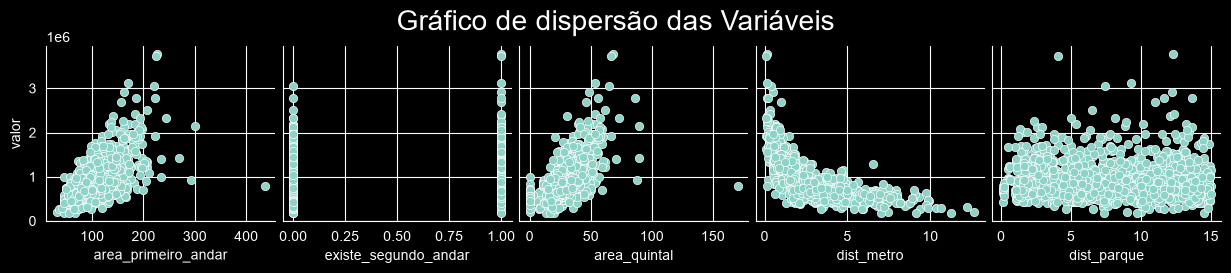

In [247]:
ax = sns.pairplot(dados, y_vars="valor", x_vars= ['area_primeiro_andar','existe_segundo_andar','area_quintal', 'dist_metro', 'dist_parque'])
ax.figure.suptitle('Gráfico de dispersão das Variáveis', fontsize=20, y=1.05)
plt.show()

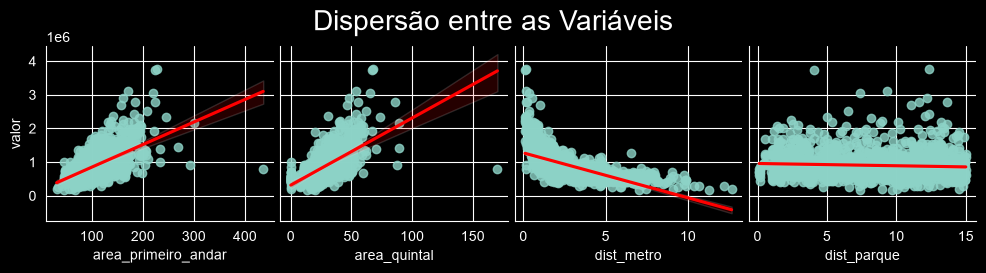

In [248]:
ax = sns.pairplot(dados, y_vars="valor", x_vars= ['area_primeiro_andar','area_quintal', 'dist_metro', 'dist_parque'],
                  kind='reg', plot_kws={'line_kws':{'color':'red'}})
ax.figure.suptitle('Dispersão entre as Variáveis', fontsize=20, y=1.05)
plt.show()

In [249]:
# Verificando se há 0 nas variáveis explicativas do nosso df
dados.describe().round(2)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque
count,1460.00,1460.00,1460.00,1460.00,1460.00,1460.00
mean,904605.98,108.01,0.43,29.47,2.77,8.15
std,397212.51,35.92,0.50,12.23,1.91,4.20
min,174500.00,31.03,0.00,0.00,0.10,0.12
25%,649875.00,81.94,0.00,22.18,1.42,4.44
50%,815000.00,100.98,0.00,27.64,2.26,8.73
75%,1070000.00,129.25,1.00,36.18,3.89,11.64
max,3775000.00,435.90,1.00,170.29,12.65,15.00


In [250]:
# Transformando as variáveis explicativas e resposta utilizando o logaritmo
dados['log_valor'] = np.log(dados['valor'])
dados['log_area_primeiro_andar'] = np.log(dados['area_primeiro_andar'])
dados['log_area_quintal'] = np.log1p(dados['area_quintal'])
dados['log_dist_metro'] = np.log(dados['dist_metro'])
dados['log_dist_parque'] = np.log(dados['dist_parque'])

In [251]:
# Lendo os dados
dados.head(3)

,valor,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro,dist_parque,log_valor,log_area_primeiro_andar,log_area_quintal,log_dist_metro,log_dist_parque
0,1042500,79.52,1,23.86,1.64,3.04,13.857132,4.376009,3.213260,0.494696,1.111858
1,907500,117.24,0,35.17,1.54,10.91,13.718449,4.764223,3.588230,0.431782,2.389680
2,1117500,85.47,1,25.64,1.27,11.79,13.926605,4.448165,3.282414,0.239017,2.467252


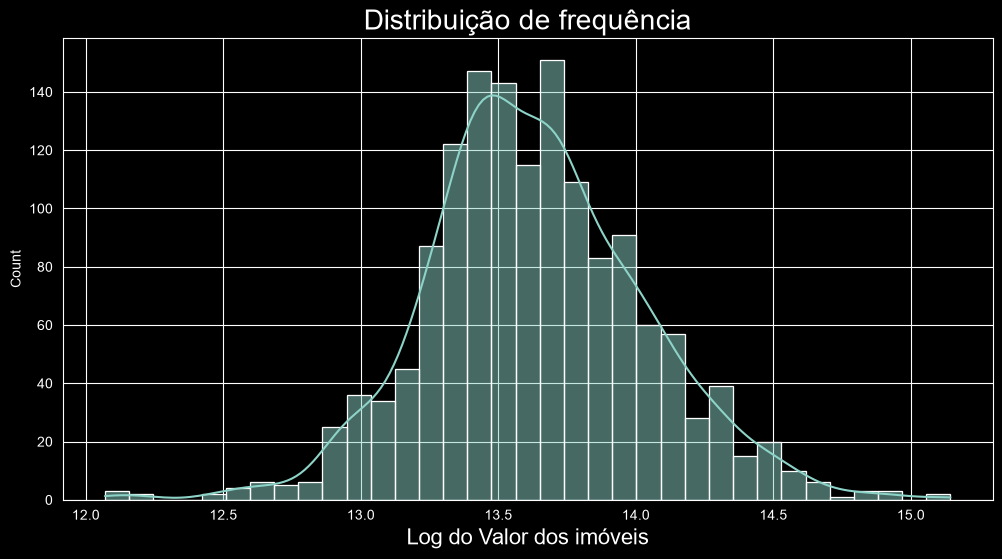

In [252]:
ax = sns.histplot(dados['log_valor'], kde=True)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de frequência', fontsize=20)
ax.set_xlabel('Log do Valor dos imóveis', fontsize=16)
plt.show()

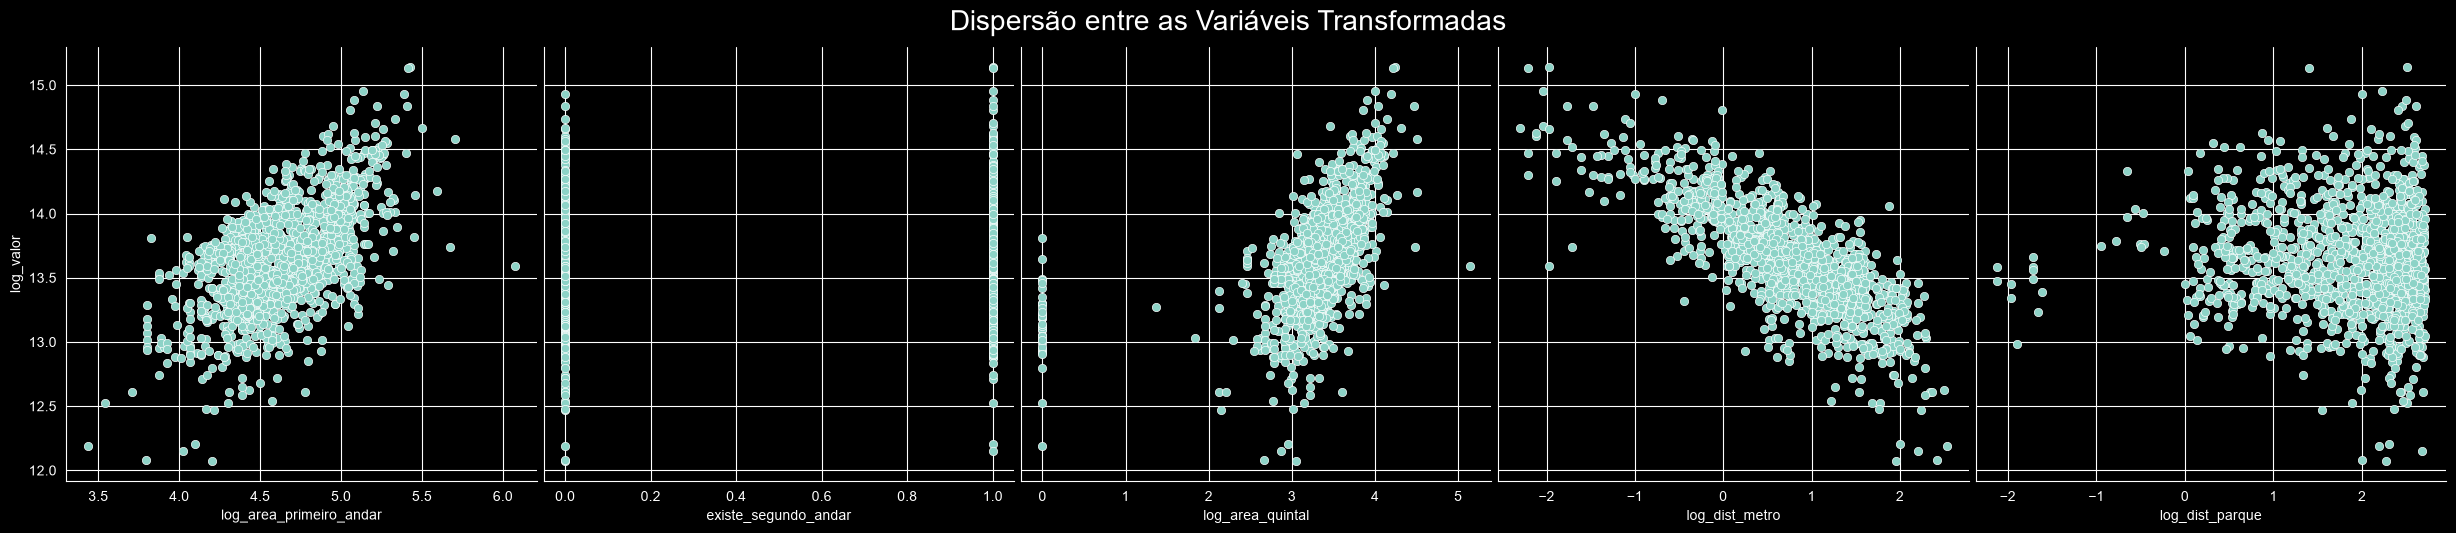

In [253]:
ax = sns.pairplot(dados, y_vars="log_valor", x_vars= ['log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal', 'log_dist_metro','log_dist_parque'], height= 5)
ax.figure.suptitle('Dispersão entre as Variáveis Transformadas', fontsize=20, y=1.05)
plt.show()

In [254]:
# Importando o método de separação dos dados de treino e teste
from sklearn.model_selection import train_test_split

In [255]:
# Definindo X e y
y = dados['log_valor']
X = dados[['log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal', 'log_dist_metro', 'log_dist_parque']]

In [256]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None
)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value

## Função: `train_test_split` (Módulo `sklearn.model_selection`)

A função `train_test_split` é uma utilidade rápida do Scikit-Learn que divide matrizes ou datasets em subconjuntos aleatórios de **treino** e **teste** de forma integrada em uma única linha de código.

### Sintaxe Básica
```python
X_train, X_test, y_train, y_test = train_test_split(
    *arrays, 
    test_size=None, 
    train_size=None, 
    random_state=None, 
    shuffle=True, 
    stratify=None
)
```

### Parâmetros Principais

* **`*arrays`**: Sequência de listas, arrays NumPy, matrizes ou DataFrames do Pandas que possuem o mesmo comprimento ou quantidade de linhas. Normalmente passamos as variáveis explicativas ($X$) e a variável alvo ($y$).
* **`test_size`** *(float ou int, padrão=None)*: Define o tamanho da base de teste. 
  * Se for um número decimal entre `0.0` e `1.0` (ex: `0.3`), representa a porcentagem dos dados reservados para teste (30%).
  * Se for um número inteiro, representa a quantidade exata de linhas.
* **`train_size`** *(float ou int, padrão=None)*: Define o tamanho da base de treino. Se não for preenchido, é calculado automaticamente como o complemento do `test_size`.
* **`random_state`** *(int, padrão=None)*: Define a semente de aleatoriedade (seed). Controla o embaralhamento dos dados antes da divisão, garantindo que o código produza exatamente o mesmo resultado toda vez que for executado (reprodutibilidade).
* **`shuffle`** *(bool, padrão=True)*: Determina se os dados devem ou não ser embaralhados antes da divisão.
* **`stratify`** *(array-like, padrão=None)*: Utilizado para estratificar os dados, garantindo que as proporções das classes na base de teste e treino sejam idênticas às do dataset original (essencial para problemas de classificação com classes desbalanceadas).


In [257]:
# Dividindo os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [258]:
# Dividindo os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1991)

In [259]:
X_train

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro,log_dist_parque
480,5.146738,0,3.952973,-1.171183,1.091923
175,5.300714,0,3.540959,0.582216,2.571084
891,4.445940,1,3.280535,0.760806,2.424803
101,4.508329,1,3.075005,0.947789,0.506818
403,4.684259,1,3.490429,-0.051293,1.864080
...,...,...,...,...,...
519,4.775250,1,3.598955,0.431782,2.296567
397,4.399130,1,3.222071,1.425515,0.215111
1331,4.484470,0,3.272985,1.202972,1.000632
1102,4.657288,0,3.372455,1.311032,1.360977


In [260]:
X_test.shape

(438, 5)

In [261]:
import statsmodels.api as sm

In [262]:
# sm.add_constant(X_train): Adiciona uma coluna cheia de números 1 (constante) à base de treino
# Isso é obrigatório no Statsmodels para calcular o intercepto (Beta 0) da equação de regressão
X_train_com_constante = sm.add_constant(X_train)


In [263]:
# .head(): Exibe as 5 primeiras linhas da base de treino estruturada
# Serve para validar visualmente se a coluna 'const' com o valor 1.0 foi adicionada com sucesso
X_train_com_constante.head()


,const,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro,log_dist_parque
480,1.0,5.146738,0,3.952973,-1.171183,1.091923
175,1.0,5.300714,0,3.540959,0.582216,2.571084
891,1.0,4.445940,1,3.280535,0.760806,2.424803
101,1.0,4.508329,1,3.075005,0.947789,0.506818
403,1.0,4.684259,1,3.490429,-0.051293,1.864080


In [264]:
modelo_statsmodels = sm.OLS(y_train, X_train_com_constante, hasconst=True).fit()
print(modelo_statsmodels.summary())

                            OLS Regression Results                            
Dep. Variable:              log_valor   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     641.8
Date:                Tue, 16 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:29:04   Log-Likelihood:                 214.97
No. Observations:                1022   AIC:                            -417.9
Df Residuals:                    1016   BIC:                            -388.4
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [265]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [266]:
# Atualizando as variáveis de entrada do modelo
X_train_novo = X_train.drop('log_dist_parque', axis=1)
X_test_novo = X_test.drop('log_dist_parque', axis=1)

In [267]:
# Verificando o X_train_novo
X_train_novo.head()

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro
480,5.146738,0,3.952973,-1.171183
175,5.300714,0,3.540959,0.582216
891,4.445940,1,3.280535,0.760806
101,4.508329,1,3.075005,0.947789
403,4.684259,1,3.490429,-0.051293


In [268]:
# Instanciando o modelo
modelo = LinearRegression()

In [269]:
# Treinando o modelo com os dados de treino
modelo.fit(X_train_novo, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.5 , 0.19, 0.08,-0.26]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['log_area_primeiro_andar','existe_segundo_andar','log_area_quintal', 'log_dist_metro']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.18
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [270]:
# round(modelo.score(...), 3): Calcula o R² do modelo e usa a função nativa round() do Python para limitar em 3 casas decimais
# Isso corrige o erro AttributeError pois a função score() retorna um número comum (float) que não aceita o método .round() direto
print(f"R² = {round(modelo.score(X_train_novo, y_train), 3)}")


R² = 0.759


In [271]:
y_previsto = modelo.predict(X_test_novo)

In [272]:
# metrics.r2_score(y_test, y_previsto): Compara os valores reais de teste com as previsões para calcular o R²
# round(..., 3): Envolve a métrica com a função nativa do Python para limitar o resultado em 3 casas decimais de forma correta
y_previsto = modelo.predict(X_test_novo)
print(f"R² = {round(metrics.r2_score(y_test, y_previsto), 3)}")


R² = 0.738


In [273]:
# Quais são as features do nosso modelo?
modelo.feature_names_in_

array(['log_area_primeiro_andar', 'existe_segundo_andar',
       'log_area_quintal', 'log_dist_metro'], dtype=object)

In [274]:
# ['var1', 'var2', ...]: Cria uma lista simples com os nomes das variáveis utilizadas no modelo de regressão
# Usar uma lista padrão do Python elimina a necessidade de importar o numpy e evita o erro NameError
colunas_modelo = ['log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal', 'log_dist_metro']


In [275]:
# Nova casa
nova_casa = pd.DataFrame({
    'log_area_primeiro_andar': [np.log(150)],
    'existe_segundo_andar': [1],
    'log_area_quintal': [np.log1p(80)],
    'log_dist_metro': [np.log(2)]
})

In [276]:
modelo.predict(nova_casa)[0]

np.float64(14.033308563946903)

In [277]:
print(f'R$ {np.exp(modelo.predict(nova_casa)[0]):,.2f}')

R$ 1,243,335.90


In [278]:
## Lendo o valor do intercepto em log
modelo.intercept_

np.float64(11.175804790479438)

In [279]:
## Transformando o efeito do intercepto em reais
np.exp(modelo.intercept_)

np.float64(71382.26945148739)

In [280]:
# Lendo os coeficientes
modelo.coef_

array([ 0.4993189 ,  0.18767146,  0.07936657, -0.2609041 ])

In [281]:
X_train_novo.columns

Index(['log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal',
       'log_dist_metro'],
      dtype='str')

In [282]:
## Criando o índice dos coeficientes
index = ['Intercepto', 'log_area_primeiro_andar', 'existe_segundo_andar', 'log_area_quintal', 'log_dist_metro']

In [283]:
## Criando o df
df_params = pd.DataFrame(data = np.append(modelo.intercept_, modelo.coef_), index=index, columns=['Parâmetros'])

In [284]:
df_params.round(3)

,Parâmetros
Intercepto,11.176
log_area_primeiro_andar,0.499
existe_segundo_andar,0.188
log_area_quintal,0.079
log_dist_metro,-0.261


In [285]:

# modelo_statsmodels.params['existe_segundo_andar']: Acessa o coeficiente da variável dummy direto do modelo treinado
# np.expm1(...): Aplica a transformação exponencial menos 1 necessária para descobrir o impacto percentual real de uma dummy em modelos log-lineares
# f'{100 * ...:.2f}%': Multiplica o resultado por 100 para transformar em porcentagem e limita a exibição a duas casas decimais
print(f'Efeito da dummy: {100 * np.expm1(modelo_statsmodels.params["existe_segundo_andar"]):.2f}%')


Efeito da dummy: 20.56%


In [286]:
# modelo.predict(X_train_novo): Realiza as previsões utilizando a matriz de treino correta com a letra X maiúscula
# Corrigir a capitalização da variável X_train_novo elimina o erro NameError causado pela sensibilidade a maiúsculas do Python
y_train_previsto = modelo.predict(X_train_novo)


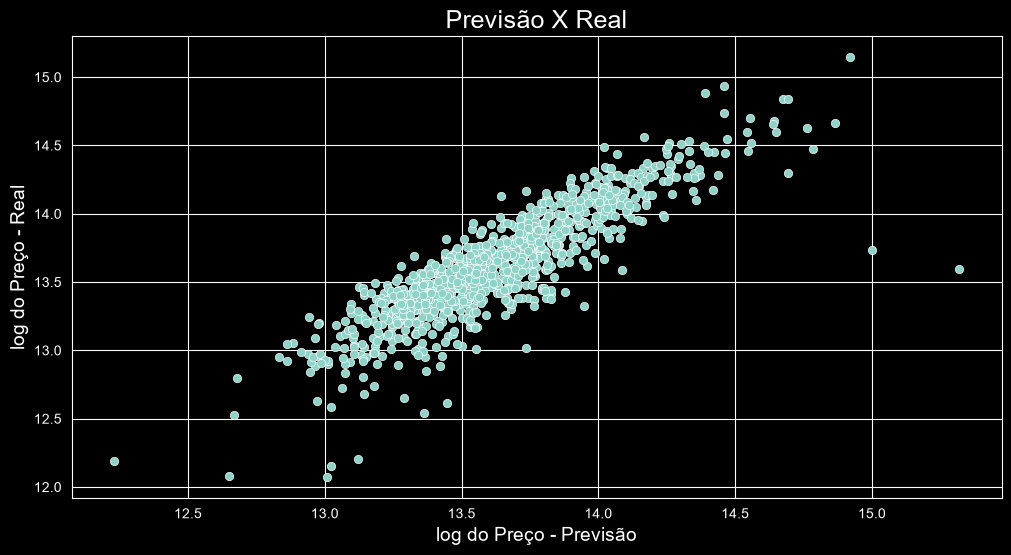

In [287]:
ax = sns.scatterplot(x=y_train_previsto, y=y_train)

ax.figure.set_size_inches(12, 6)
ax.set_title('Previsão X Real', fontsize=18)
ax.set_xlabel('log do Preço - Previsão', fontsize=14)
ax.set_ylabel('log do Preço - Real', fontsize=14)
plt.show()

In [288]:
residuo = y_train - y_train_previsto

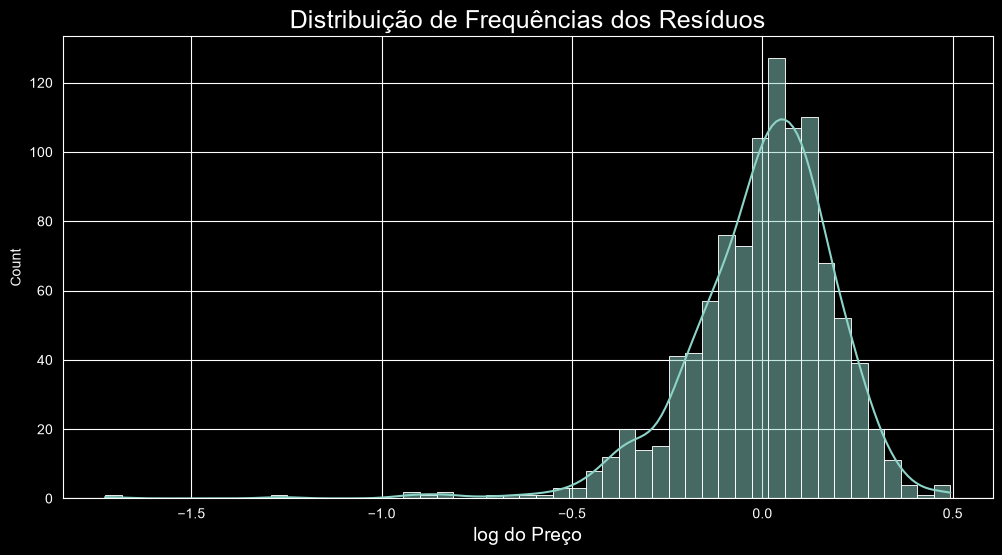

In [289]:
ax = sns.histplot(residuo, kde = True)

ax.figure.set_size_inches(12, 6)
ax.set_title('Distribuição de Frequências dos Resíduos', fontsize=18)
ax.set_xlabel('log do Preço', fontsize=14)
plt.show()

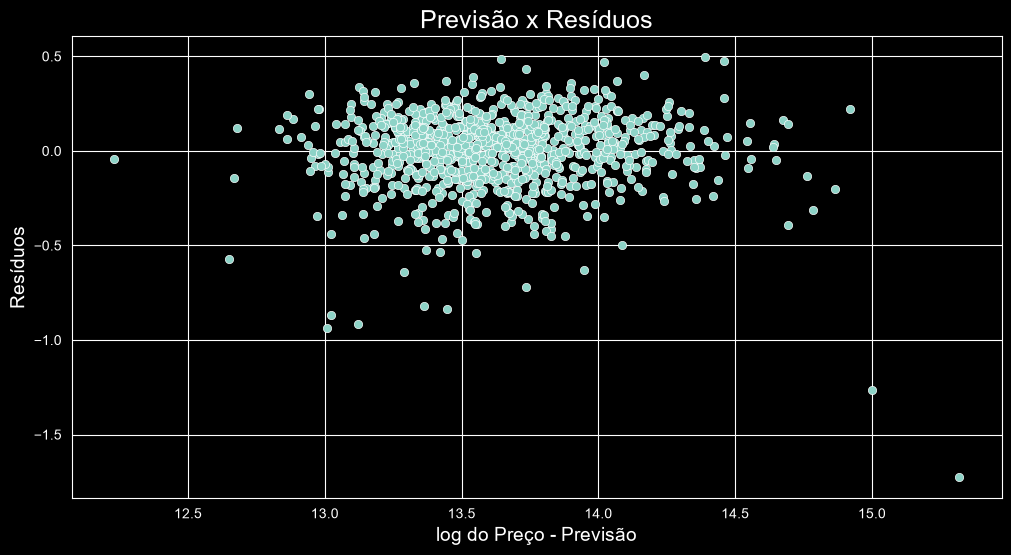

In [290]:
ax = sns.scatterplot(x=y_train_previsto, y=residuo)

ax.figure.set_size_inches(12, 6)
ax.set_title('Previsão x Resíduos', fontsize=18)
ax.set_xlabel('log do Preço - Previsão', fontsize=14)
ax.set_ylabel('Resíduos', fontsize=14)
plt.show()

In [291]:
import pickle

In [292]:
arquivo = open('modelo_casas_a_precificar.pkl', 'wb')
pickle.dump(modelo, arquivo)
arquivo.close()

In [293]:
import pandas as pd
import numpy as np

In [294]:
arquivo = open('Modelos/modelo_casas_a_precificar.pkl.pkl', 'wb')
pickle.dump(modelo, arquivo)
arquivo.close()

In [295]:
import pandas as pd
import numpy as np

In [296]:
# pd.read_csv('Dados/...'): Aponta para o caminho correto dentro da pasta 'Dados' onde a base de dados foi salva localmente
# casas.head(): Exibe as primeiras cinco linhas do DataFrame carregado para validar o sucesso da importação dos dados brutos
casas = pd.read_csv('Dados/casas_a_precificar.csv')
casas.head()

,area_primeiro_andar,existe_segundo_andar,area_quintal,dist_metro
0,180,1,40,8.0
1,130,0,80,1.0
2,170,1,60,7.5
3,250,1,70,4.0
4,260,0,70,8.5


In [297]:
casas.columns = ["log_area_primeiro_andar", "existe_segundo_andar", "log_area_quintal", "log_dist_metro"]

In [298]:
casas["log_area_primeiro_andar"] = np.log(casas["log_area_primeiro_andar"])
casas["log_area_quintal"] = np.log(casas["log_area_quintal"])
casas["log_dist_metro"] = np.log(casas["log_dist_metro"])

In [299]:
casas["log_area_primeiro_andar"] = np.log(casas["log_area_primeiro_andar"])
casas["log_area_quintal"] = np.log1p(casas["log_area_quintal"])
casas["log_dist_metro"] = np.log(casas["log_dist_metro"])

c:\Users\vagne\OneDrive\Documentos\Projetos Alura\aprendendo-ml\Regress-linear\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [300]:
casas

,log_area_primeiro_andar,existe_segundo_andar,log_area_quintal,log_dist_metro
0,1.647303,1,1.545194,0.732099
1,1.582588,0,1.683065,-inf
2,1.636235,1,1.628131,0.700571
3,1.708642,1,1.657941,0.326634
4,1.715721,0,1.657941,0.760837
5,1.667389,0,1.781986,-0.902720
6,1.741130,0,1.781986,0.475885
7,1.566007,0,1.628131,0.834032
8,1.566007,1,1.723689,-0.902720
9,1.566007,1,1.545194,0.700571
